# 06 - Test per gruppi indipendenti (EXP vs SHAM) per nodo

Per ciascuno dei 16 nodi (DMNa, DMNp, SAL, OLF, STR, AUD, VIS, TH, MOp, SSp, SSs, HCa, SUB, CTXsp, BF, HY) confrontiamo EXP vs SHAM con:
- test parametrico: `scipy.stats.ttest_ind` (Welch, `equal_var=False`)
- test non parametrico: `scipy.stats.mannwhitneyu`

seguiti da una correzione per confronti multipli (FDR / Benjamini-Hochberg).

## Step 1 - Inventario dei dati

Prima di tutto esploriamo `outputs/community_detection/leiden_flex_*` per capire quali scan sono disponibili.
Organizziamo i soggetti in un dizionario `{data: [topi]}`:
- la chiave e' la data dello scan (es. `230908`)
- i valori sono le lettere dei topi scansionati quel giorno (es. `a`, `b`, `c`, `d`)

In [1]:
import os
import re
from collections import defaultdict
from glob import glob

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ttest_rel, mannwhitneyu, wilcoxon

In [ ]:
OUTPUTS_DIR = "../outputs/community_detection"


def latest_leiden_output_dir(outputs_dir: str, dataset: str) -> str:
    """Return the most recently produced outputs/community_detection/leiden_flex_<n_runs>_<timestamp>/ dir containing `dataset`."""
    candidates = [
        d for d in glob(os.path.join(outputs_dir, "leiden_flex_*"))
        if os.path.isdir(os.path.join(d, dataset))
    ]
    assert candidates, f"No leiden_flex_* output directories containing {dataset!r} found in {outputs_dir}"
    return max(candidates, key=os.path.getmtime)


DATASET = "Bf_DTA_anes"
LEIDEN_DIR = latest_leiden_output_dir(OUTPUTS_DIR, DATASET)
LEIDEN_DIR

In [3]:
# Le cartelle soggetto hanno il formato "sub-<prefisso><data>", es. "sub-ag230908".
# All'interno, ogni scan e' "sub-<prefisso><data><topo>_<condition>...csv", es. "sub-ag230908a_EXP_bold_parcellated.csv".
SUBJECT_DIR_RE = re.compile(r"^sub-[a-zA-Z]+(\d+)$")

subjects_by_date = defaultdict(set)

subject_dirs = glob(os.path.join(LEIDEN_DIR, DATASET, "*", "sub-*"))

for subject_dir in subject_dirs:
    subject_folder = os.path.basename(subject_dir)
    match = SUBJECT_DIR_RE.match(subject_folder)
    if not match:
        continue
    date = match.group(1)

    for csv_path in glob(os.path.join(subject_dir, "*.csv")):
        scan_id = os.path.basename(csv_path).split("_")[0]  # es. "sub-ag230908a"
        mouse = scan_id[len(subject_folder):]  # es. "a"
        subjects_by_date[date].add(mouse)

subjects_by_date = {date: sorted(mice) for date, mice in sorted(subjects_by_date.items())}
subjects_by_date

{'230908': ['a'],
 '230911': ['a', 'b', 'c', 'd'],
 '230912': ['a', 'b', 'c', 'd'],
 '230913': ['a', 'b', 'c', 'd'],
 '230914': ['a', 'b', 'c', 'd'],
 '230915': ['a'],
 '230918': ['a', 'b', 'c', 'd'],
 '230919': ['a', 'b', 'c', 'd'],
 '230920': ['a', 'b', 'c'],
 '230921': ['a', 'b', 'c', 'd'],
 '230922': ['a', 'b', 'c', 'd'],
 '230925': ['a', 'b', 'c'],
 '230926': ['a', 'b']}

In [4]:
n_dates = len(subjects_by_date)
n_scans = sum(len(mice) for mice in subjects_by_date.values())
print(f"{n_dates} date, {n_scans} scan totali")

13 date, 42 scan totali


## Test Parametrico

In [5]:
exp_records = []
sham_records = []

for date, mice in subjects_by_date.items():
    counts = {"EXP": 0, "SHAM": 0}
    for mouse in mice:
        # "mouse" is just a letter (e.g. "a"), find the matching scan csv
        csv_paths = glob(os.path.join(LEIDEN_DIR, DATASET, "*", f"sub-*{date}", f"sub-*{date}{mouse}_*.csv"))
        for csv_path in csv_paths:
            condition = os.path.basename(csv_path).split("_")[1]  # "EXP" or "SHAM"
            df = pd.read_csv(csv_path)
            df["date"] = date
            df["mouse"] = mouse
            df["condition"] = condition

            if condition == "EXP":
                exp_records.append(df)
            elif condition == "SHAM":
                sham_records.append(df)

            counts[condition] = counts.get(condition, 0) + 1

    # alcune date hanno un numero diverso di scan EXP vs SHAM: i due gruppi
    # restano indipendenti e non vanno appaiati per topo
    print(f"{date}: {counts['EXP']} EXP, {counts['SHAM']} SHAM")

exp_df = pd.concat(exp_records, ignore_index=True)
sham_df = pd.concat(sham_records, ignore_index=True)

print(f"\nTotale: {exp_df[['date', 'mouse']].drop_duplicates().shape[0]} scan EXP, "
      f"{sham_df[['date', 'mouse']].drop_duplicates().shape[0]} scan SHAM")

230908: 1 EXP, 0 SHAM
230911: 2 EXP, 2 SHAM
230912: 2 EXP, 2 SHAM
230913: 2 EXP, 2 SHAM
230914: 1 EXP, 3 SHAM
230915: 1 EXP, 0 SHAM
230918: 1 EXP, 3 SHAM
230919: 3 EXP, 1 SHAM
230920: 1 EXP, 2 SHAM
230921: 2 EXP, 2 SHAM
230922: 3 EXP, 1 SHAM
230925: 2 EXP, 1 SHAM
230926: 1 EXP, 1 SHAM

Totale: 22 scan EXP, 20 scan SHAM


In [6]:
nodes = sorted(exp_df["Node"].unique())

ttest_results = []
for node in nodes:
    exp_vals = exp_df.loc[exp_df["Node"] == node, "flexibility"]
    sham_vals = sham_df.loc[sham_df["Node"] == node, "flexibility"]

    t_stat, p_value = ttest_ind(exp_vals, sham_vals, equal_var=False)

    ttest_results.append({
        "Node": node,
        "n_EXP": len(exp_vals),
        "n_SHAM": len(sham_vals),
        "mean_EXP": exp_vals.mean(),
        "mean_SHAM": sham_vals.mean(),
        "t_stat": t_stat,
        "p_value": p_value,
    })

ttest_results = pd.DataFrame(ttest_results)
ttest_results

,Node,n_EXP,n_SHAM,mean_EXP,mean_SHAM,t_stat,p_value
0,AUD,22,20,0.116486,0.118607,-0.587758,0.560000
1,BF,22,20,0.120697,0.119823,0.304830,0.762184
2,CTXsp,22,20,0.124450,0.124908,-0.116151,0.908278
3,DMNa,22,20,0.119487,0.122377,-0.617034,0.540815
4,DMNp,22,20,0.123041,0.131345,-1.904146,0.065015
5,HCa,22,20,0.130295,0.133892,-0.686177,0.496669
6,HY,22,20,0.111328,0.114540,-0.805304,0.425503
7,MOp,22,20,0.126074,0.127067,-0.216691,0.829603
8,OLF,22,20,0.118676,0.125322,-1.737719,0.090024
9,SAL,22,20,0.123577,0.130545,-1.577548,0.123104


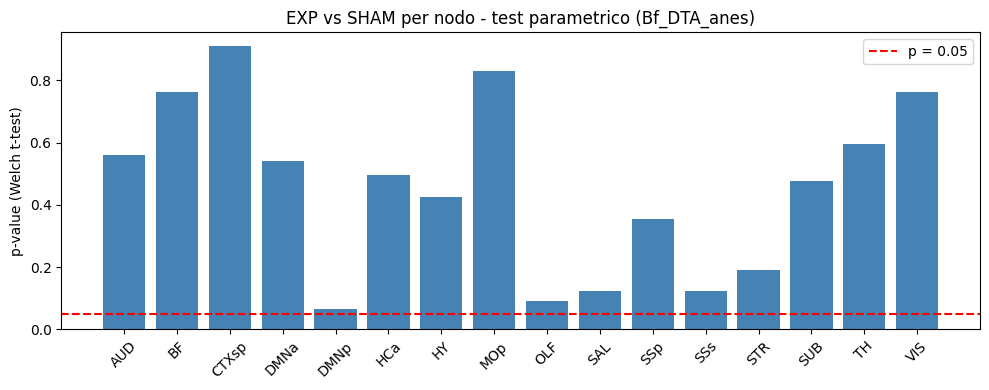

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ttest_results["Node"], ttest_results["p_value"], color="steelblue")
ax.axhline(0.05, color="red", linestyle="--", label="p = 0.05")
ax.set_ylabel("p-value (Welch t-test)")
ax.set_title(f"EXP vs SHAM per nodo - test parametrico ({DATASET})")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
nodes = sorted(exp_df["Node"].unique())

ttest_results = []
for node in nodes:
    exp_vals = exp_df.loc[exp_df["Node"] == node, "flexibility"]
    sham_vals = sham_df.loc[sham_df["Node"] == node, "flexibility"]

    u_stat, p_val = mannwhitneyu(exp_vals, sham_vals, alternative='two-sided')

    ttest_results.append({
        "Node": node,
        "n_EXP": len(exp_vals),
        "n_SHAM": len(sham_vals),
        "mean_EXP": exp_vals.mean(),
        "mean_SHAM": sham_vals.mean(),
        "u_stat": u_stat,
        "p_value": p_val,
    })

ttest_results = pd.DataFrame(ttest_results)
ttest_results

,Node,n_EXP,n_SHAM,mean_EXP,mean_SHAM,u_stat,p_value
0,AUD,22,20,0.116486,0.118607,207.0,0.752862
1,BF,22,20,0.120697,0.119823,203.5,0.686974
2,CTXsp,22,20,0.124450,0.124908,210.0,0.810911
3,DMNa,22,20,0.119487,0.122377,184.5,0.378055
4,DMNp,22,20,0.123041,0.131345,130.0,0.024196
5,HCa,22,20,0.130295,0.133892,192.0,0.488580
6,HY,22,20,0.111328,0.114540,194.5,0.528918
7,MOp,22,20,0.126074,0.127067,203.5,0.686974
8,OLF,22,20,0.118676,0.125322,128.5,0.021908
9,SAL,22,20,0.123577,0.130545,165.0,0.169894


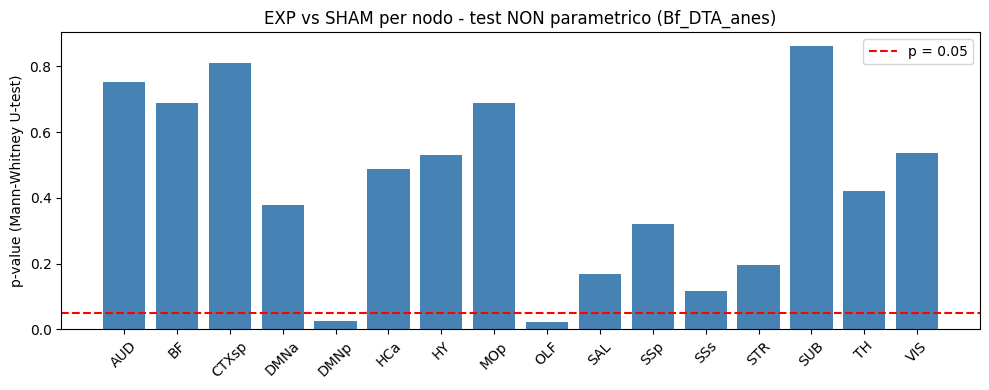

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ttest_results["Node"], ttest_results["p_value"], color="steelblue")
ax.axhline(0.05, color="red", linestyle="--", label="p = 0.05")
ax.set_ylabel("p-value (Mann-Whitney U-test)")
ax.set_title(f"EXP vs SHAM per nodo - test NON parametrico ({DATASET})")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bf_PV_anes

Stessa logica di confronto EXP vs SHAM per nodo (t-test parametrico + Mann-Whitney non
parametrico), applicata al dataset `Bf_PV_anes` (DREADD su neuroni PV, mice anestetizzati).

**Nota:** in `Bf_PV_anes` ogni topo ha due file separati per scan, uno per la fase
`baseline` e uno per la fase `CNO` (vedi `for_ludo/README.txt`). La logica di caricamento
qui sotto e' identica a quella usata per `Bf_DTA_anes` e quindi raccoglie **entrambe le
fasi** per ogni topo come osservazioni distinte (n_EXP/n_SHAM ~ 2x il numero di topi).
Ogni topo contribuisce quindi due osservazioni correlate (non indipendenti) allo stesso
test — se si vuole isolare l'effetto del CNO andrebbe fatta un'analisi separata per fase
(baseline vs CNO) o un confronto within-subject.

In [10]:
DATASET = "Bf_PV_anes"
LEIDEN_DIR = latest_leiden_output_dir(OUTPUTS_DIR, DATASET)
LEIDEN_DIR

'outputs/leiden_flex_20_20260612_042319'

In [11]:
subjects_by_date = defaultdict(set)

subject_dirs = glob(os.path.join(LEIDEN_DIR, DATASET, "*", "sub-*"))

for subject_dir in subject_dirs:
    subject_folder = os.path.basename(subject_dir)
    match = SUBJECT_DIR_RE.match(subject_folder)
    if not match:
        continue
    date = match.group(1)

    for csv_path in glob(os.path.join(subject_dir, "*.csv")):
        scan_id = os.path.basename(csv_path).split("_")[0]
        mouse = scan_id[len(subject_folder):]
        subjects_by_date[date].add(mouse)

subjects_by_date = {date: sorted(mice) for date, mice in sorted(subjects_by_date.items())}
subjects_by_date

{'240718': ['a', 'b'],
 '240719': ['b', 'c'],
 '240722': ['a'],
 '240723': ['a'],
 '240724': ['a', 'b', 'c'],
 '240725': ['a', 'b', 'c'],
 '240726': ['a', 'b', 'c'],
 '240729': ['a', 'b', 'c', 'd'],
 '240730': ['a', 'b', 'c', 'd'],
 '240731': ['a', 'b', 'c'],
 '240801': ['b', 'c', 'd'],
 '240802': ['a', 'c', 'd'],
 '240806': ['a', 'b', 'c'],
 '240807': ['a', 'b', 'c'],
 '240808': ['a', 'b', 'c']}

In [12]:
n_dates = len(subjects_by_date)
n_scans = sum(len(mice) for mice in subjects_by_date.values())
print(f"{n_dates} date, {n_scans} scan totali")

15 date, 41 scan totali


In [13]:
exp_records = []
sham_records = []

for date, mice in subjects_by_date.items():
    counts = {"EXP": 0, "SHAM": 0}
    for mouse in mice:
        # "mouse" is just a letter (e.g. "a"), find the matching scan csv
        csv_paths = glob(os.path.join(LEIDEN_DIR, DATASET, "*", f"sub-*{date}", f"sub-*{date}{mouse}_*.csv"))
        for csv_path in csv_paths:
            condition = os.path.basename(csv_path).split("_")[1]  # "EXP" or "SHAM"
            df = pd.read_csv(csv_path)
            df["date"] = date
            df["mouse"] = mouse
            df["condition"] = condition

            if condition == "EXP":
                exp_records.append(df)
            elif condition == "SHAM":
                sham_records.append(df)

            counts[condition] = counts.get(condition, 0) + 1

    # ogni topo ha file separati per fase "baseline" e "CNO": entrambi finiscono qui
    # come osservazioni distinte (vedi nota nella cella markdown sopra)
    print(f"{date}: {counts['EXP']} EXP, {counts['SHAM']} SHAM")

exp_df = pd.concat(exp_records, ignore_index=True)
sham_df = pd.concat(sham_records, ignore_index=True)

print(f"\nTotale: {exp_df[['date', 'mouse']].drop_duplicates().shape[0]} topi EXP, "
      f"{sham_df[['date', 'mouse']].drop_duplicates().shape[0]} topi SHAM "
      f"({len(exp_records)} osservazioni EXP, {len(sham_records)} osservazioni SHAM "
      f"incl. fasi baseline/CNO)")

240718: 2 EXP, 2 SHAM
240719: 2 EXP, 2 SHAM
240722: 2 EXP, 0 SHAM
240723: 0 EXP, 2 SHAM
240724: 2 EXP, 3 SHAM
240725: 4 EXP, 2 SHAM
240726: 2 EXP, 4 SHAM
240729: 4 EXP, 4 SHAM
240730: 6 EXP, 2 SHAM
240731: 2 EXP, 4 SHAM
240801: 2 EXP, 3 SHAM
240802: 6 EXP, 0 SHAM
240806: 4 EXP, 2 SHAM
240807: 4 EXP, 2 SHAM
240808: 0 EXP, 6 SHAM

Totale: 21 topi EXP, 20 topi SHAM (42 osservazioni EXP, 38 osservazioni SHAM incl. fasi baseline/CNO)


In [14]:
nodes = sorted(exp_df["Node"].unique())

ttest_results = []
for node in nodes:
    exp_vals = exp_df.loc[exp_df["Node"] == node, "flexibility"]
    sham_vals = sham_df.loc[sham_df["Node"] == node, "flexibility"]

    t_stat, p_value = ttest_ind(exp_vals, sham_vals, equal_var=False)

    ttest_results.append({
        "Node": node,
        "n_EXP": len(exp_vals),
        "n_SHAM": len(sham_vals),
        "mean_EXP": exp_vals.mean(),
        "mean_SHAM": sham_vals.mean(),
        "t_stat": t_stat,
        "p_value": p_value,
    })

ttest_results = pd.DataFrame(ttest_results)
ttest_results

,Node,n_EXP,n_SHAM,mean_EXP,mean_SHAM,t_stat,p_value
0,AUD,42,38,0.122093,0.120551,0.424136,0.672883
1,BF,42,38,0.121369,0.123693,-0.684995,0.495490
2,CTXsp,42,38,0.123159,0.123114,0.013528,0.989243
3,DMNa,42,38,0.128909,0.125962,0.722046,0.472705
4,DMNp,42,38,0.124759,0.124756,0.000952,0.999243
5,HCa,42,38,0.130534,0.130413,0.031627,0.974853
6,HY,42,38,0.120470,0.119715,0.235392,0.814534
7,MOp,42,38,0.121345,0.122373,-0.280746,0.779701
8,OLF,42,38,0.125639,0.125508,0.036553,0.970948
9,SAL,42,38,0.120349,0.118671,0.478054,0.634011


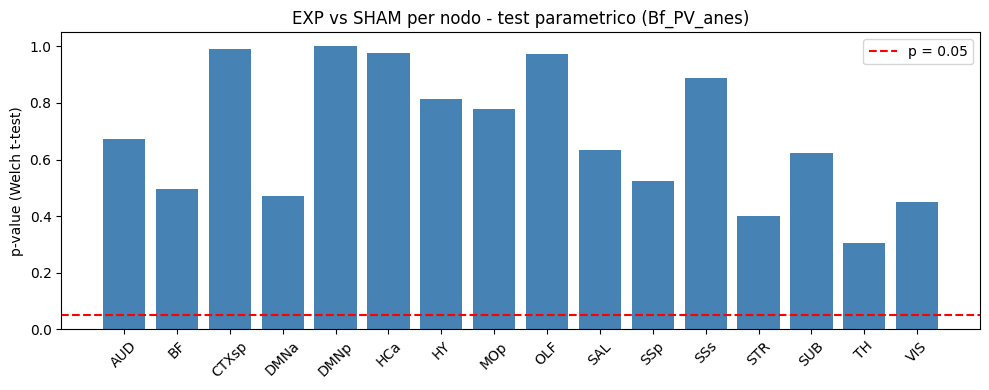

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ttest_results["Node"], ttest_results["p_value"], color="steelblue")
ax.axhline(0.05, color="red", linestyle="--", label="p = 0.05")
ax.set_ylabel("p-value (Welch t-test)")
ax.set_title(f"EXP vs SHAM per nodo - test parametrico ({DATASET})")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
nodes = sorted(exp_df["Node"].unique())

ttest_results = []
for node in nodes:
    exp_vals = exp_df.loc[exp_df["Node"] == node, "flexibility"]
    sham_vals = sham_df.loc[sham_df["Node"] == node, "flexibility"]

    u_stat, p_val = mannwhitneyu(exp_vals, sham_vals, alternative='two-sided')

    ttest_results.append({
        "Node": node,
        "n_EXP": len(exp_vals),
        "n_SHAM": len(sham_vals),
        "mean_EXP": exp_vals.mean(),
        "mean_SHAM": sham_vals.mean(),
        "u_stat": u_stat,
        "p_value": p_val,
    })

ttest_results = pd.DataFrame(ttest_results)
ttest_results

,Node,n_EXP,n_SHAM,mean_EXP,mean_SHAM,u_stat,p_value
0,AUD,42,38,0.122093,0.120551,794.5,0.976941
1,BF,42,38,0.121369,0.123693,675.0,0.237902
2,CTXsp,42,38,0.123159,0.123114,750.5,0.650674
3,DMNa,42,38,0.128909,0.125962,843.0,0.668110
4,DMNp,42,38,0.124759,0.124756,751.0,0.654146
5,HCa,42,38,0.130534,0.130413,770.0,0.791048
6,HY,42,38,0.120470,0.119715,818.5,0.847199
7,MOp,42,38,0.121345,0.122373,744.0,0.606235
8,OLF,42,38,0.125639,0.125508,757.0,0.696387
9,SAL,42,38,0.120349,0.118671,819.5,0.839661


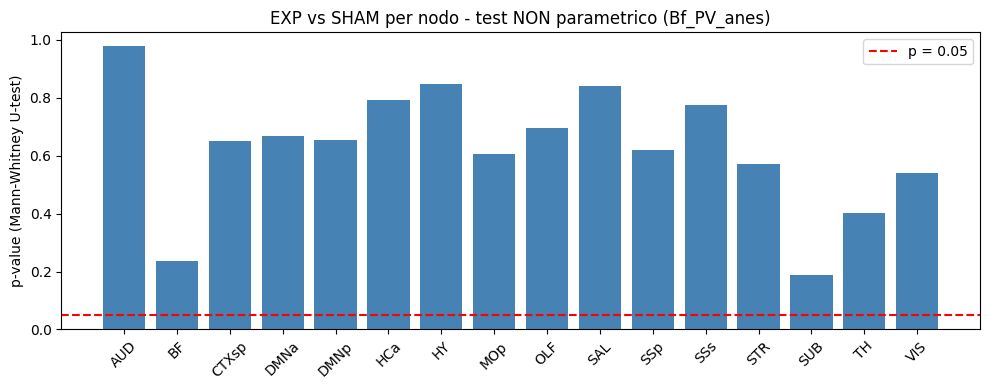

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(ttest_results["Node"], ttest_results["p_value"], color="steelblue")
ax.axhline(0.05, color="red", linestyle="--", label="p = 0.05")
ax.set_ylabel("p-value (Mann-Whitney U-test)")
ax.set_title(f"EXP vs SHAM per nodo - test NON parametrico ({DATASET})")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Bf_PV_anes: confronti separati per fase

Per non mescolare il gruppo sperimentale (`EXP`/`SHAM`) con la fase dello scan
(`baseline`/`CNO`), eseguiamo due analisi separate:

1. **baseline vs CNO** all'interno di ciascun gruppo, con test appaiati per topo;
2. **EXP vs SHAM nella sola fase CNO**, con test per gruppi indipendenti.

Il confronto appaiato usa solo i topi che hanno entrambe le fasi disponibili.

In [18]:
phase_records = []

for csv_path in sorted(glob(os.path.join(LEIDEN_DIR, DATASET, "*", "sub-*", "*.csv"))):
    filename = os.path.basename(csv_path)
    parts = filename.replace(".csv", "").split("_")
    subject = parts[0]
    condition = parts[1]

    if "baseline" in parts:
        phase = "baseline"
    elif "CNO" in parts:
        phase = "CNO"
    else:
        continue

    df = pd.read_csv(csv_path)
    df["subject"] = subject
    df["condition"] = condition
    df["phase"] = phase
    phase_records.append(df)

phase_df = pd.concat(phase_records, ignore_index=True)

scan_inventory = (
    phase_df[["subject", "condition", "phase"]]
    .drop_duplicates()
    .groupby(["condition", "phase"])
    .size()
    .rename("n_scans")
    .reset_index()
)
scan_inventory

,condition,phase,n_scans
0,EXP,CNO,21
1,EXP,baseline,21
2,SHAM,CNO,20
3,SHAM,baseline,18


In [19]:
paired_phase_results = []

for condition in ["EXP", "SHAM"]:
    paired = (
        phase_df.loc[phase_df["condition"] == condition]
        .pivot(index=["subject", "Node"], columns="phase", values="flexibility")
        .dropna(subset=["baseline", "CNO"])
        .reset_index()
    )

    for node in sorted(paired["Node"].unique()):
        node_pairs = paired.loc[paired["Node"] == node]
        baseline_vals = node_pairs["baseline"]
        cno_vals = node_pairs["CNO"]

        t_stat, t_p_value = ttest_rel(cno_vals, baseline_vals)
        w_stat, w_p_value = wilcoxon(cno_vals, baseline_vals, alternative="two-sided")

        paired_phase_results.append({
            "condition": condition,
            "Node": node,
            "n_pairs": len(node_pairs),
            "mean_baseline": baseline_vals.mean(),
            "mean_CNO": cno_vals.mean(),
            "mean_difference_CNO_minus_baseline": (cno_vals - baseline_vals).mean(),
            "t_stat": t_stat,
            "t_p_value": t_p_value,
            "w_stat": w_stat,
            "w_p_value": w_p_value,
        })

paired_phase_results = pd.DataFrame(paired_phase_results)
paired_phase_results

,condition,Node,n_pairs,mean_baseline,mean_CNO,mean_difference_CNO_minus_baseline,t_stat,t_p_value,w_stat,w_p_value
0,EXP,AUD,21,0.122132,0.122054,-0.000078,-0.022570,0.982217,113.0,0.945745
1,EXP,BF,21,0.122142,0.120596,-0.001546,-0.499944,0.622571,111.0,0.891732
2,EXP,CTXsp,21,0.122092,0.124227,0.002135,0.658899,0.517476,93.0,0.452368
3,EXP,DMNa,21,0.130109,0.127708,-0.002401,-0.837419,0.412253,87.0,0.337660
4,EXP,DMNp,21,0.124541,0.124978,0.000437,0.153170,0.879799,115.0,1.000000
5,EXP,HCa,21,0.132034,0.129034,-0.003000,-1.088191,0.289451,90.0,0.392584
6,EXP,HY,21,0.121506,0.119435,-0.002071,-0.887615,0.385298,92.0,0.431911
7,EXP,MOp,21,0.121984,0.120706,-0.001279,-0.366036,0.718182,103.0,0.682714
8,EXP,OLF,21,0.125536,0.125742,0.000207,0.092608,0.927136,110.0,0.864887
9,EXP,SAL,21,0.120903,0.119796,-0.001107,-0.303547,0.764608,102.0,0.657827


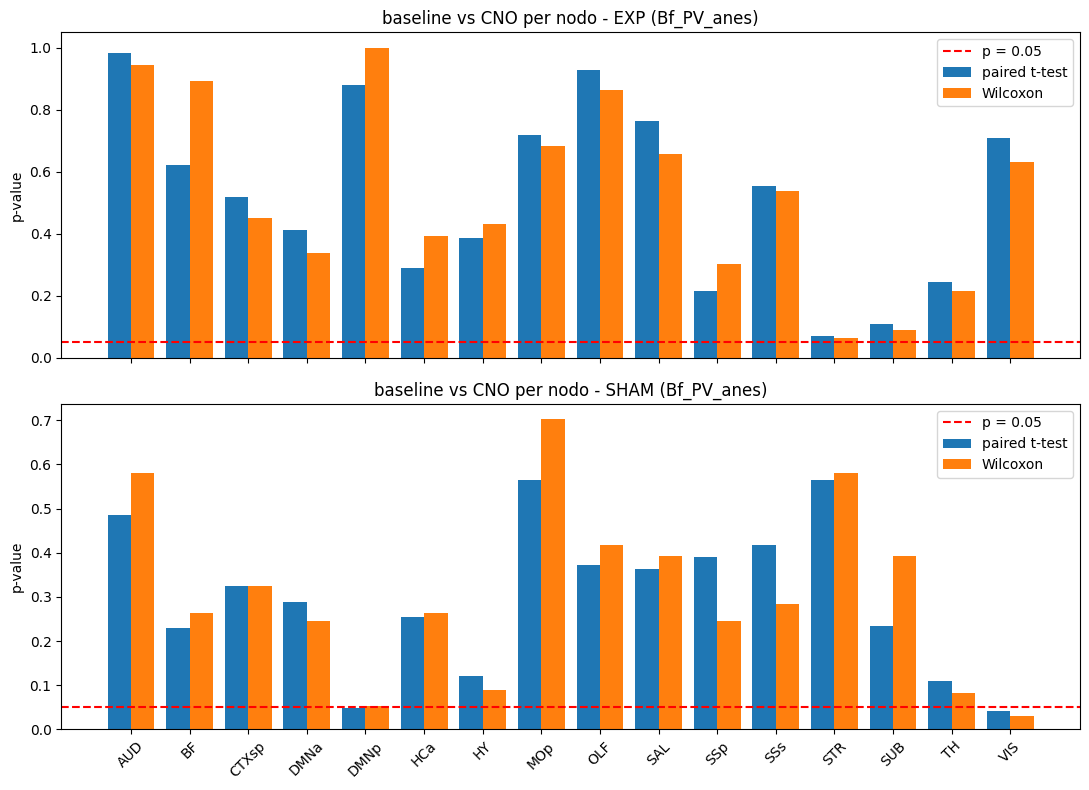

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for ax, condition in zip(axes, ["EXP", "SHAM"]):
    results = paired_phase_results.loc[paired_phase_results["condition"] == condition]
    x = range(len(results))
    ax.bar([i - 0.2 for i in x], results["t_p_value"], width=0.4, label="paired t-test")
    ax.bar([i + 0.2 for i in x], results["w_p_value"], width=0.4, label="Wilcoxon")
    ax.axhline(0.05, color="red", linestyle="--", label="p = 0.05")
    ax.set_ylabel("p-value")
    ax.set_title(f"baseline vs CNO per nodo - {condition} ({DATASET})")
    ax.legend()

axes[-1].set_xticks(range(len(results)))
axes[-1].set_xticklabels(results["Node"], rotation=45)
plt.tight_layout()
plt.show()

In [21]:
cno_df = phase_df.loc[phase_df["phase"] == "CNO"]
cno_group_results = []

for node in sorted(cno_df["Node"].unique()):
    exp_vals = cno_df.loc[
        (cno_df["condition"] == "EXP") & (cno_df["Node"] == node),
        "flexibility",
    ]
    sham_vals = cno_df.loc[
        (cno_df["condition"] == "SHAM") & (cno_df["Node"] == node),
        "flexibility",
    ]

    t_stat, t_p_value = ttest_ind(exp_vals, sham_vals, equal_var=False)
    u_stat, u_p_value = mannwhitneyu(exp_vals, sham_vals, alternative="two-sided")

    cno_group_results.append({
        "Node": node,
        "n_EXP": len(exp_vals),
        "n_SHAM": len(sham_vals),
        "mean_EXP": exp_vals.mean(),
        "mean_SHAM": sham_vals.mean(),
        "t_stat": t_stat,
        "t_p_value": t_p_value,
        "u_stat": u_stat,
        "u_p_value": u_p_value,
    })

cno_group_results = pd.DataFrame(cno_group_results)
cno_group_results

,Node,n_EXP,n_SHAM,mean_EXP,mean_SHAM,t_stat,t_p_value,u_stat,u_p_value
0,AUD,21,20,0.122054,0.121659,0.087325,0.931018,196.0,0.724758
1,BF,21,20,0.120596,0.125559,-1.133840,0.264916,139.5,0.067877
2,CTXsp,21,20,0.124227,0.124984,-0.162976,0.871483,170.0,0.302897
3,DMNa,21,20,0.127708,0.128137,-0.075773,0.940039,182.0,0.473197
4,DMNp,21,20,0.124978,0.128464,-0.653142,0.518112,162.0,0.215384
5,HCa,21,20,0.129034,0.132839,-0.733929,0.468196,161.0,0.205879
6,HY,21,20,0.119435,0.121285,-0.416582,0.679518,180.5,0.449402
7,MOp,21,20,0.120706,0.121506,-0.172761,0.863896,174.0,0.354450
8,OLF,21,20,0.125742,0.127420,-0.320963,0.750266,180.0,0.441644
9,SAL,21,20,0.119796,0.119778,0.003914,0.996906,169.0,0.290821


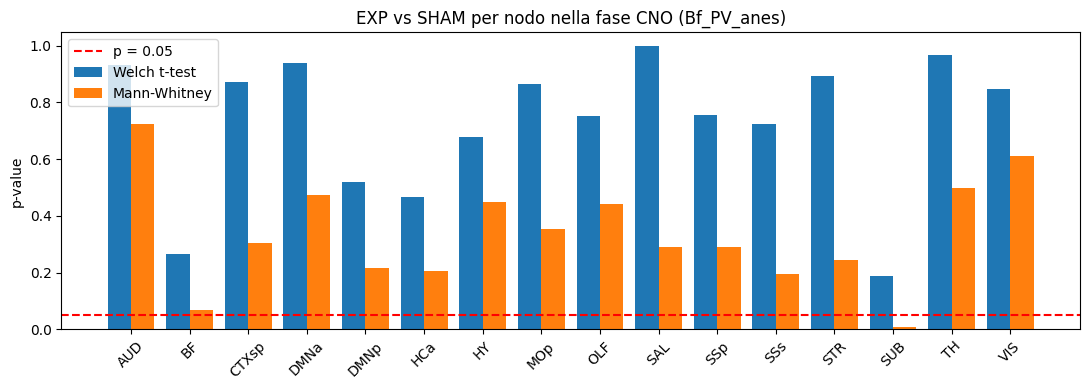

In [22]:
fig, ax = plt.subplots(figsize=(11, 4))
x = range(len(cno_group_results))
ax.bar([i - 0.2 for i in x], cno_group_results["t_p_value"], width=0.4, label="Welch t-test")
ax.bar([i + 0.2 for i in x], cno_group_results["u_p_value"], width=0.4, label="Mann-Whitney")
ax.axhline(0.05, color="red", linestyle="--", label="p = 0.05")
ax.set_xticks(list(x))
ax.set_xticklabels(cno_group_results["Node"], rotation=45)
ax.set_ylabel("p-value")
ax.set_title(f"EXP vs SHAM per nodo nella fase CNO ({DATASET})")
ax.legend()
plt.tight_layout()
plt.show()

## Bf_PV_anes: difference-in-differences (effetto specifico del CNO)

Il confronto appaiato `baseline → CNO` da solo non isola l'effetto del DREADD: anche i topi
SHAM possono cambiare flessibilità tra le due fasi (deriva temporale, effetto aspecifico del
CNO). La **difference-in-differences (DiD)** rimuove questa deriva:

1. per ogni topo calcoliamo Δ = flessibilità(CNO) − flessibilità(baseline);
2. confrontiamo Δ_EXP vs Δ_SHAM (gruppi indipendenti, Welch + Mann-Whitney).

Un Δ più negativo negli EXP che negli SHAM indica che il silenziamento PV nel BF *riduce* la
flessibilità in modo specifico. Aggiungiamo una correzione FDR (Benjamini-Hochberg) sui 16 nodi.

In [23]:
import numpy as np


def benjamini_hochberg(pvals):
    """Return Benjamini-Hochberg FDR-adjusted p-values, in the input order."""
    p = np.asarray(pvals, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adjusted = p[order] * n / (np.arange(n) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]  # enforce monotonicity
    out = np.empty(n)
    out[order] = np.clip(adjusted, 0, 1)
    return out


def difference_in_differences(flex_df):
    """Per-node DiD test: is (CNO - baseline) different between EXP and SHAM?

    Expects a tidy frame with columns subject, condition, phase, Node, flexibility.
    Only animals that have BOTH phases contribute. Returns one row per node with
    raw Welch / Mann-Whitney p-values plus their FDR-corrected counterparts.
    """
    deltas = (
        flex_df
        .pivot_table(index=["subject", "condition", "Node"], columns="phase", values="flexibility")
        .dropna(subset=["baseline", "CNO"])
        .reset_index()
    )
    deltas["delta"] = deltas["CNO"] - deltas["baseline"]

    rows = []
    for node in sorted(deltas["Node"].unique()):
        d_exp = deltas.loc[(deltas.condition == "EXP") & (deltas.Node == node), "delta"]
        d_sham = deltas.loc[(deltas.condition == "SHAM") & (deltas.Node == node), "delta"]
        _, t_p = ttest_ind(d_exp, d_sham, equal_var=False)
        _, u_p = mannwhitneyu(d_exp, d_sham, alternative="two-sided")
        rows.append({
            "Node": node,
            "n_EXP": len(d_exp), "n_SHAM": len(d_sham),
            "delta_EXP": d_exp.mean(), "delta_SHAM": d_sham.mean(),
            "DiD": d_exp.mean() - d_sham.mean(),
            "t_p_value": t_p, "u_p_value": u_p,
        })
    res = pd.DataFrame(rows)
    res["t_p_fdr"] = benjamini_hochberg(res["t_p_value"])
    res["u_p_fdr"] = benjamini_hochberg(res["u_p_value"])
    return res.sort_values("t_p_value").reset_index(drop=True)


did_results = difference_in_differences(phase_df)
did_results

,Node,n_EXP,n_SHAM,delta_EXP,delta_SHAM,DiD,t_p_value,u_p_value,t_p_fdr,u_p_fdr
0,TH,21,18,-0.003241,0.004209,-0.007450,0.050283,0.088307,0.315048,0.275253
1,SUB,21,18,-0.004314,0.004873,-0.009187,0.060491,0.111451,0.315048,0.275253
2,VIS,21,18,-0.001127,0.006910,-0.008037,0.072354,0.035835,0.315048,0.275253
3,HY,21,18,-0.002071,0.003680,-0.005751,0.084935,0.117927,0.315048,0.275253
4,HCa,21,18,-0.003000,0.004351,-0.007351,0.120635,0.154830,0.315048,0.275253
5,STR,21,18,-0.005714,0.002474,-0.008188,0.122986,0.105258,0.315048,0.275253
6,DMNp,21,18,0.000437,0.007123,-0.006685,0.138632,0.124695,0.315048,0.275253
7,SSp,21,18,-0.003352,0.003359,-0.006711,0.157524,0.099342,0.315048,0.275253
8,DMNa,21,18,-0.002401,0.004820,-0.007221,0.179175,0.139135,0.318533,0.275253
9,BF,21,18,-0.001546,0.004208,-0.005754,0.216614,0.303822,0.346582,0.441923


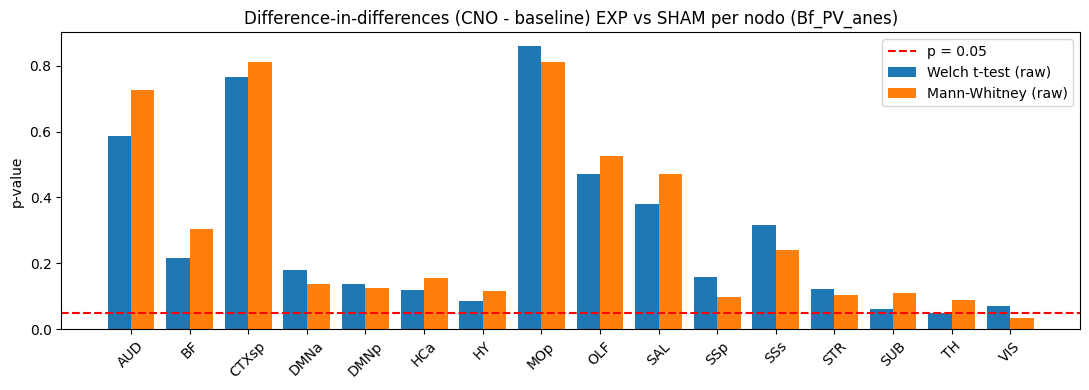

In [24]:
order = did_results.sort_values("Node")
x = range(len(order))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar([i - 0.2 for i in x], order["t_p_value"], width=0.4, label="Welch t-test (raw)")
ax.bar([i + 0.2 for i in x], order["u_p_value"], width=0.4, label="Mann-Whitney (raw)")
ax.axhline(0.05, color="red", linestyle="--", label="p = 0.05")
ax.set_xticks(list(x))
ax.set_xticklabels(order["Node"], rotation=45)
ax.set_ylabel("p-value")
ax.set_title(f"Difference-in-differences (CNO - baseline) EXP vs SHAM per nodo ({DATASET})")
ax.legend()
plt.tight_layout()
plt.show()

## L'overlap delle finestre comprime la flessibilità

La flessibilità è calcolata su finestre scorrevoli di 35 TR con passo 3 TR
(`02_make_windows.py`): finestre adiacenti condividono 32/35 TR → **91% di overlap**. I
pattern di connettività di finestre adiacenti sono quasi identici (r ≈ 0.94), mentre finestre
distanti ~12 passi sono di fatto indipendenti (r ≈ 0.06). La partizione in comunità quindi
non ha motivo di cambiare tra finestre adiacenti e la flessibilità collassa in una banda
stretta attorno a ~0.12, schiacciando ogni differenza EXP/SHAM.

Per verificarlo ricalcoliamo la flessibilità **sottocampionando** le finestre già presenti in
`outputs/window_connectivity/` (una ogni `k`), cioè passo effettivo = 3·k TR, riusando la stessa
community detection di `04_run_community_detection.py`. Confrontiamo lo stato attuale
(`k=1`, passo 3 TR) con finestre ~non sovrapposte (`k=12`, passo 36 TR ≈ lunghezza finestra).

In [ ]:
import sys
import importlib.util
from collections import defaultdict

# Reuse the community-detection code from script 04. We register the module in
# sys.modules so the forked Leiden workers can re-import it (otherwise the
# dynamically loaded module is unpicklable across the process boundary).
_spec = importlib.util.spec_from_file_location("cd04", "04_run_community_detection.py")
cd04 = importlib.util.module_from_spec(_spec)
sys.modules["cd04"] = cd04
_spec.loader.exec_module(cd04)

CONNECTIVITY_DIR = "../outputs/window_connectivity"


def scan_windows(dataset):
    """Return {scan_id: sorted [(window_id, path)]} for a dataset's connectivity matrices."""
    files = sorted(glob(os.path.join(CONNECTIVITY_DIR, dataset, "*", "*", "*", "*.csv")))
    groups = defaultdict(list)
    for path in files:
        _, scan_id, window_id = cd04.parse_filename(path)
        groups[scan_id].append((window_id, path))
    return {scan_id: sorted(wins) for scan_id, wins in groups.items()}


def recompute_flexibility(dataset, step_mult, n_runs=10, gamma=0.35, omega=0.25):
    """Recompute per-node flexibility using every `step_mult`-th existing window.

    step_mult=1 reproduces the current pipeline (step 3 TR); larger values reduce
    window overlap (effective step = 3*step_mult TR). Returns a tidy DataFrame with
    columns subject, condition, phase, Node, flexibility, step_mult, n_windows.
    """
    scans = scan_windows(dataset)
    records = []
    for i, (scan_id, wins) in enumerate(scans.items(), 1):
        sub = wins[::step_mult]
        if len(sub) < 3:
            continue
        res = cd04.run_community_detection(sub, n_runs=n_runs, gamma=gamma, omega=omega, run_workers=4)
        parts = scan_id.split("_")
        condition = parts[1]
        phase = "CNO" if "CNO" in parts else ("baseline" if "baseline" in parts else "full")
        for _, row in res.iterrows():
            records.append({
                "subject": parts[0], "condition": condition, "phase": phase,
                "Node": row["Node"], "flexibility": row["flexibility"],
                "step_mult": step_mult, "n_windows": len(sub),
            })
        print(f"  [{i}/{len(scans)}] {scan_id}  ({len(sub)} windows)", end="\r")
    print()
    return pd.DataFrame(records)

In [ ]:
# k=1 (step 3 TR) is the current pipeline output, already loaded above as phase_df.
flex_step3 = phase_df[["subject", "condition", "phase", "Node", "flexibility"]].assign(step_mult=1)

# k=12 (step 36 TR, ~non-overlapping). Recomputes the 80 Bf_PV_anes scans (~5 min).
flex_step36 = recompute_flexibility(DATASET, step_mult=12, n_runs=10)
flex_step36.to_csv(os.path.join("..", "outputs", "flexibility", "flexibility_step36_Bf_PV_anes.csv"), index=False)
flex_step36.head()

Flessibilità su tutti i nodi e tutti gli scan:
  step 3  (k=1, attuale)         mean=0.124  std=0.0163  range=[0.055, 0.174]
  step 36 (k=12, ~no overlap)    mean=0.466  std=0.0773  range=[0.144, 0.691]


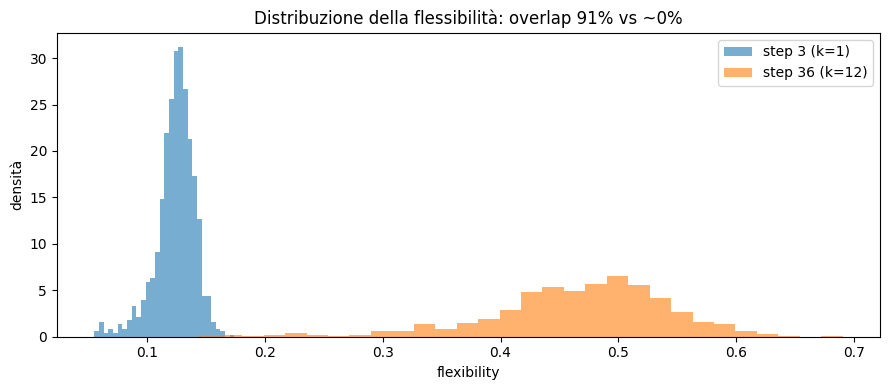

In [27]:
print("Flessibilità su tutti i nodi e tutti gli scan:")
for label, d in [("step 3  (k=1, attuale)", flex_step3), ("step 36 (k=12, ~no overlap)", flex_step36)]:
    v = d["flexibility"]
    print(f"  {label:30s} mean={v.mean():.3f}  std={v.std():.4f}  range=[{v.min():.3f}, {v.max():.3f}]")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(flex_step3["flexibility"], bins=30, alpha=0.6, density=True, label="step 3 (k=1)")
ax.hist(flex_step36["flexibility"], bins=30, alpha=0.6, density=True, label="step 36 (k=12)")
ax.set_xlabel("flexibility")
ax.set_ylabel("densità")
ax.set_title("Distribuzione della flessibilità: overlap 91% vs ~0%")
ax.legend()
plt.tight_layout()
plt.show()

### Le statistiche migliorano con finestre non sovrapposte?

Rifacciamo sia il confronto **EXP vs SHAM nella sola fase CNO** sia la **DiD** sui dati a
passo 36 e li mettiamo a confronto con il passo 3. Se la compressione da overlap è la causa,
la separazione tra gruppi (p-value più bassi, |DiD| più grande) deve aumentare.

In [28]:
def cno_group_test(flex_df):
    """Per-node EXP vs SHAM (independent groups) on the CNO phase only."""
    cno = flex_df[flex_df.phase == "CNO"]
    rows = []
    for node in sorted(cno["Node"].unique()):
        e = cno.loc[(cno.condition == "EXP") & (cno.Node == node), "flexibility"]
        s = cno.loc[(cno.condition == "SHAM") & (cno.Node == node), "flexibility"]
        _, t_p = ttest_ind(e, s, equal_var=False)
        _, u_p = mannwhitneyu(e, s, alternative="two-sided")
        rows.append({"Node": node, "t_p_value": t_p, "u_p_value": u_p})
    return pd.DataFrame(rows)


did_step36 = difference_in_differences(flex_step36)

compare = (
    did_results[["Node", "DiD", "t_p_value", "u_p_value"]]
    .rename(columns={"DiD": "DiD_s3", "t_p_value": "DiD_tp_s3", "u_p_value": "DiD_up_s3"})
    .merge(
        did_step36[["Node", "DiD", "t_p_value", "u_p_value"]]
        .rename(columns={"DiD": "DiD_s36", "t_p_value": "DiD_tp_s36", "u_p_value": "DiD_up_s36"}),
        on="Node",
    )
    .sort_values("DiD_tp_s36")
    .reset_index(drop=True)
)
compare

,Node,DiD_s3,DiD_tp_s3,DiD_up_s3,DiD_s36,DiD_tp_s36,DiD_up_s36
0,TH,-0.007450,0.050283,0.088307,-0.047781,0.024493,0.021676
1,SSs,-0.004151,0.315417,0.242351,0.039202,0.032598,0.023340
2,DMNp,-0.006685,0.138632,0.124695,-0.048840,0.040747,0.073629
3,HY,-0.005751,0.084935,0.117927,-0.041264,0.050746,0.047021
4,VIS,-0.008037,0.072354,0.035835,-0.039952,0.099892,0.154830
5,HCa,-0.007351,0.120635,0.154830,-0.028104,0.251229,0.359885
6,STR,-0.008188,0.122986,0.105258,-0.016902,0.561659,0.662356
7,AUD,-0.002849,0.586812,0.724728,0.013683,0.595512,0.745956
8,CTXsp,-0.001440,0.765494,0.810749,0.007370,0.717357,0.854706
9,BF,-0.005754,0.216614,0.303822,0.007163,0.760617,0.745956


In [29]:
cno3 = cno_group_test(flex_step3).rename(columns={"t_p_value": "tp_s3", "u_p_value": "up_s3"})
cno36 = cno_group_test(flex_step36).rename(columns={"t_p_value": "tp_s36", "u_p_value": "up_s36"})
cno_compare = cno3.merge(cno36, on="Node").sort_values("up_s36").reset_index(drop=True)

print("EXP vs SHAM nella fase CNO - Mann-Whitney p-value, passo 3 vs passo 36:")
print(f"  nodi con p<0.05 a passo 3 : {(cno_compare['up_s3'] < 0.05).sum()}")
print(f"  nodi con p<0.05 a passo 36: {(cno_compare['up_s36'] < 0.05).sum()}")
cno_compare

EXP vs SHAM nella fase CNO - Mann-Whitney p-value, passo 3 vs passo 36:
  nodi con p<0.05 a passo 3 : 1
  nodi con p<0.05 a passo 36: 0


,Node,tp_s3,up_s3,tp_s36,up_s36
0,HY,0.679518,0.449402,0.330191,0.147742
1,BF,0.264916,0.067877,0.395296,0.151409
2,DMNp,0.518112,0.215384,0.419545,0.162862
3,SUB,0.186842,0.008110,0.578929,0.225160
4,HCa,0.468196,0.205879,0.477404,0.315260
5,MOp,0.863896,0.354450,0.879076,0.334485
6,SSp,0.755273,0.290821,0.654530,0.426322
7,TH,0.965759,0.497669,0.844872,0.473197
8,OLF,0.750266,0.441644,0.572569,0.489324
9,STR,0.892416,0.245784,0.819564,0.611002
